In [4]:
!pip install ultralytics opencv-python-headless tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.4 MB/s eta 0:00:0000:0100:01


In [5]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
# Find your dataset input path
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level <= 2:
        print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/abhinavkishan123


In [35]:
BASE = "/kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset"
# Change this line in Cell 4:
BASE_IMG_DIR = f"{BASE}"  # just BASE, no /img at all
PARTITION_FILE = f"{BASE}/list_eval_partition.txt"
BBOX_FILE      = f"{BASE}/list_bbox_inshop.txt"

WORK_DIR   = "/kaggle/working/deepfashion"
CROP_DIR   = f"{WORK_DIR}/cropped"
SPLITS_DIR = f"{WORK_DIR}/splits"

os.makedirs(CROP_DIR, exist_ok=True)
os.makedirs(SPLITS_DIR, exist_ok=True)

print("Partition file exists:", os.path.exists(PARTITION_FILE))
print("BBox file exists:     ", os.path.exists(BBOX_FILE))
print("Image dir exists:     ", os.path.exists(BASE_IMG_DIR))

Partition file exists: True
BBox file exists:      True
Image dir exists:      True


In [9]:
with open(PARTITION_FILE, "r") as f:
    lines = f.readlines()

print("Line 0 (count):", lines[0].strip())
print("Line 1 (header):", lines[1].strip())
print("Line 2 (sample):", lines[2].strip())
print("Line 3 (sample):", lines[3].strip())

Line 0 (count): 52712
Line 1 (header): image_name item_id evaluation_status
Line 2 (sample): img/WOMEN/Dresses/id_00000002/02_1_front.jpg                           id_00000002 train
Line 3 (sample): img/WOMEN/Dresses/id_00000002/02_2_side.jpg                            id_00000002 train


In [28]:
data = [line.strip().split() for line in lines[2:]]
df = pd.DataFrame(data, columns=["image_name", "item_id", "evaluation_status"])

# Add img/ prefix to match bbox_lookup keys
df["image_name"] = "img/" + df["image_name"]

train_df   = df[df["evaluation_status"] == "train"].reset_index(drop=True)
query_df   = df[df["evaluation_status"] == "query"].reset_index(drop=True)
gallery_df = df[df["evaluation_status"] == "gallery"].reset_index(drop=True)

print(f"Train:   {len(train_df)}")
print(f"Query:   {len(query_df)}")
print(f"Gallery: {len(gallery_df)}")

# Verify keys match
print("\nSample bbox key:", list(bbox_lookup.keys())[0])
print("Sample df key:  ", df["image_name"].iloc[0])

Train:   25882
Query:   14218
Gallery: 12612

Sample bbox key: img/img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg
Sample df key:   img/img/WOMEN/Dresses/id_00000002/02_1_front.jpg


In [29]:
# We'll use bbox annotations as fallback when YOLO fails
with open(BBOX_FILE, "r") as f:
    bbox_lines = f.readlines()

print("Line 0:", bbox_lines[0].strip())
print("Line 1:", bbox_lines[1].strip())
print("Line 2:", bbox_lines[2].strip())
print("Line 3:", bbox_lines[3].strip())

Line 0: 52712
Line 1: image_name clothes_type pose_type x_1 y_1 x_2 y_2
Line 2: img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg                    1 1 050 049 208 235
Line 3: img/WOMEN/Blouses_Shirts/id_00000001/02_2_side.jpg                     1 2 119 048 136 234


In [37]:
bbox_data = [line.strip().split() for line in bbox_lines[2:]]

# Typical format: image_name clothes_type source x_1 y_1 x_2 y_2
bbox_df = pd.DataFrame(bbox_data, columns=[
    "image_name", "clothes_type", "source", "x1", "y1", "x2", "y2"
])
bbox_df[["x1","y1","x2","y2"]] = bbox_df[["x1","y1","x2","y2"]].astype(int)

bbox_lookup = {
    "img/" + row["image_name"]: (row["x1"], row["y1"], row["x2"], row["y2"])
    for _, row in bbox_df.iterrows()
}

# Verify fix
print("Sample bbox key:", list(bbox_lookup.keys())[0])
print("Sample df key:  ", df["image_name"].iloc[0])

print(f"BBox entries loaded: {len(bbox_lookup)}")
bbox_df.head()

Sample bbox key: img/img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg
Sample df key:   img/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
BBox entries loaded: 52712


,image_name,clothes_type,source,x1,y1,x2,y2
0,img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...,1,1,50,49,208,235
1,img/WOMEN/Blouses_Shirts/id_00000001/02_2_side...,1,2,119,48,136,234
2,img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...,1,3,50,42,213,240
3,img/WOMEN/Blouses_Shirts/id_00000001/02_4_full...,1,4,82,30,162,129
4,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,3,1,65,45,233,252


Path: /kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
Exists: True
Size: (256, 256) Mode: RGB


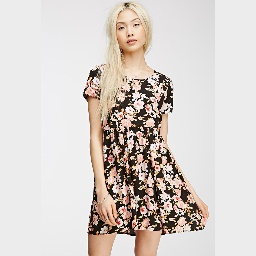

In [36]:
sample_path = os.path.join(BASE_IMG_DIR, df["image_name"].iloc[0])
print("Path:", sample_path)
print("Exists:", os.path.exists(sample_path))

img = Image.open(sample_path)
print("Size:", img.size, "Mode:", img.mode)
display(img)

In [14]:
model = YOLO("yolov8n.pt")
print("YOLO loaded!")

YOLO loaded!


Source: YOLO | Box: (81,1,212,256)


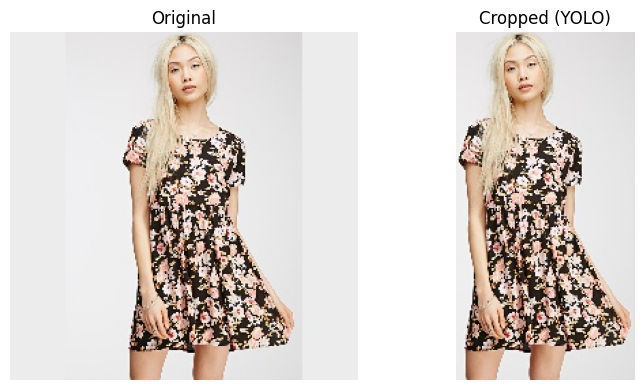

In [38]:
import matplotlib.pyplot as plt
sample_name = df["image_name"].iloc[0]
sample_path = os.path.join(BASE_IMG_DIR, sample_name)
img = Image.open(sample_path).convert("RGB")

results = model(sample_path, verbose=False)
boxes = results[0].boxes

if boxes is not None and len(boxes) > 0:
    best_idx = boxes.conf.argmax().item()
    x1, y1, x2, y2 = boxes.xyxy[best_idx].tolist()
    source = "YOLO"
elif sample_name in bbox_lookup:
    x1, y1, x2, y2 = bbox_lookup[sample_name]
    source = "BBox annotation"
else:
    x1, y1, x2, y2 = 0, 0, img.width, img.height
    source = "Full image fallback"

cropped = img.crop((x1, y1, x2, y2))
print(f"Source: {source} | Box: ({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(cropped); axes[1].set_title(f"Cropped ({source})"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [46]:
def preprocess_crop(img, x1, y1, x2, y2, padding=0.3):  # increased from 0.1 to 0.3
    w, h = img.size
    box_w = x2 - x1
    box_h = y2 - y1
    
    pad_x = int(box_w * padding)
    pad_y = int(box_h * padding)
    
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)
    
    cropped = img.crop((x1, y1, x2, y2))
    return cropped.resize((224, 224), Image.LANCZOS)

In [55]:
stats = {"yolo": 0, "bbox": 0, "full": 0, "error": 0}

MIN_BBOX_RATIO = 0.25

def crop_product(image_name, model, conf_threshold=0.25):
    image_path = os.path.join(BASE_IMG_DIR, image_name)
    save_path  = os.path.join(CROP_DIR, image_name)
    
    try:
        img = Image.open(image_path).convert("RGB")
        w, h = img.size

        if image_name in bbox_lookup:
            x1, y1, x2, y2 = bbox_lookup[image_name]
            box_w = x2 - x1
            box_h = y2 - y1
            
            # If bbox too narrow or too short, use full image
            if (box_w / w) < MIN_BBOX_RATIO or (box_h / h) < MIN_BBOX_RATIO:
                x1, y1, x2, y2 = 0, 0, w, h
                stats["full"] += 1
            else:
                stats["bbox"] += 1
        else:
            results = model(image_path, verbose=False)
            boxes = results[0].boxes
            if boxes is not None and len(boxes) > 0:
                conf_mask = boxes.conf >= conf_threshold
                filtered = boxes[conf_mask]
                if len(filtered) > 0:
                    best_idx = filtered.conf.argmax().item()
                    x1, y1, x2, y2 = [int(v) for v in filtered.xyxy[best_idx].tolist()]
                    stats["yolo"] += 1
                else:
                    raise ValueError("low conf")
            else:
                x1, y1, x2, y2 = 0, 0, w, h
                stats["full"] += 1

        cropped = preprocess_crop(img, x1, y1, x2, y2, padding=0.1)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cropped.save(save_path, quality=95)
        return True

    except Exception as e:
        stats["error"] += 1
        return False

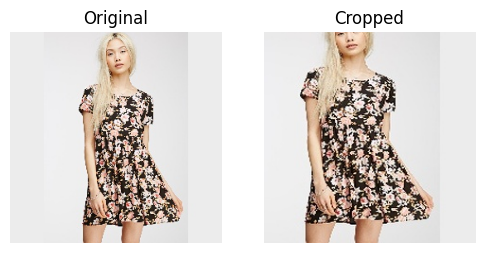

In [41]:
stats = {"yolo": 0, "bbox": 0, "full": 0, "error": 0}
for _, row in df.head(5).iterrows():
    crop_product(row["image_name"], model)

test_img_name = df["image_name"].iloc[0]
orig = Image.open(os.path.join(BASE_IMG_DIR, test_img_name))
crop = Image.open(os.path.join(CROP_DIR, test_img_name))

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(orig); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(crop); axes[1].set_title("Cropped"); axes[1].axis("off")
plt.show()

In [57]:
errors = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Cropping"):
    success = crop_product(row["image_name"], model)
    if not success:
        errors.append(row["image_name"])

print(f"\n✅ Done! {len(df)} images processed")
print(f"   YOLO detections:    {stats['yolo']}  ({stats['yolo']/len(df)*100:.1f}%)")
print(f"   BBox fallback:      {stats['bbox']}  ({stats['bbox']/len(df)*100:.1f}%)")
print(f"   Full img fallback:  {stats['full']}  ({stats['full']/len(df)*100:.1f}%)")
print(f"   Errors:             {stats['error']}")

Cropping: 100%|██████████| 52712/52712 [04:53<00:00, 179.90it/s]


✅ Done! 52712 images processed
   YOLO detections:    0  (0.0%)
   BBox fallback:      41172  (78.1%)
   Full img fallback:  11544  (21.9%)
   Errors:             0


In [58]:
train_df.to_csv(f"{SPLITS_DIR}/train.csv", index=False)
query_df.to_csv(f"{SPLITS_DIR}/query.csv", index=False)
gallery_df.to_csv(f"{SPLITS_DIR}/gallery.csv", index=False)

if errors:
    with open(f"{SPLITS_DIR}/errors.txt", "w") as f:
        f.write("\n".join(errors))

print(f"train.csv:   {len(train_df)} rows")
print(f"query.csv:   {len(query_df)} rows")
print(f"gallery.csv: {len(gallery_df)} rows")

train.csv:   25882 rows
query.csv:   14218 rows
gallery.csv: 12612 rows


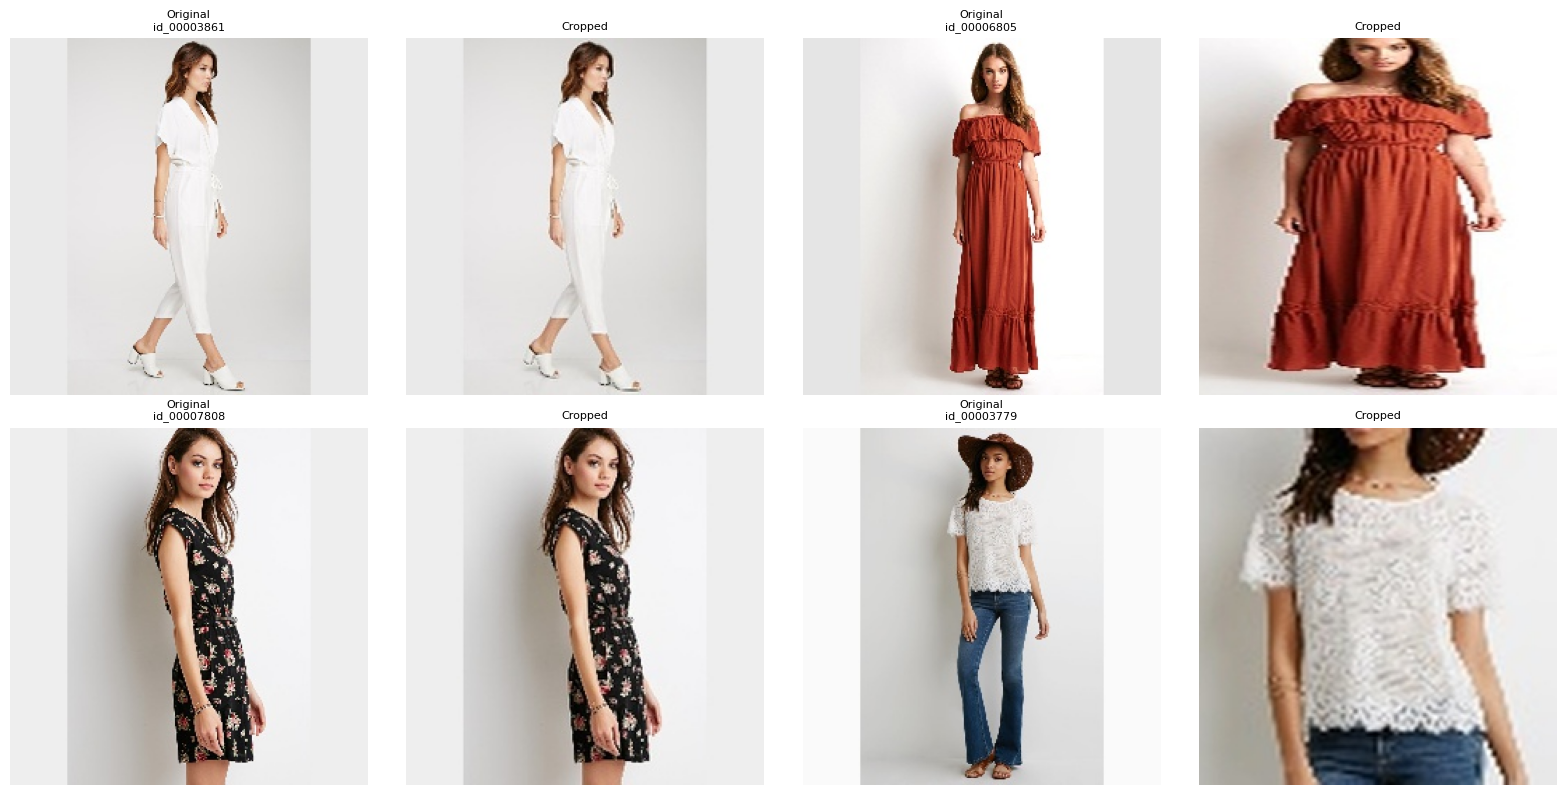

In [65]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(query_df.sample(4, random_state=42).iterrows()):
    orig_path = os.path.join(BASE_IMG_DIR, row["image_name"])
    crop_path = os.path.join(CROP_DIR, row["image_name"])
    
    axes[i*2].imshow(Image.open(orig_path))
    axes[i*2].set_title(f"Original\n{row['item_id']}", fontsize=8)
    axes[i*2].axis("off")
    
    axes[i*2+1].imshow(Image.open(crop_path))
    axes[i*2+1].set_title("Cropped", fontsize=8)
    axes[i*2+1].axis("off")

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/crop_samples.png", dpi=100)  # overwrites old one
plt.show()

In [60]:
shutil.make_archive("/kaggle/working/splits", "zip", SPLITS_DIR)
print("✅ splits.zip ready")
print("\nNext step: Save notebook output as a Kaggle Dataset")
print("so teammates P2 and P3 can mount cropped images directly.")

✅ splits.zip ready

Next step: Save notebook output as a Kaggle Dataset
so teammates P2 and P3 can mount cropped images directly.


In [61]:
import shutil

shutil.copy(f"{SPLITS_DIR}/train.csv", f"{CROP_DIR}/train.csv")
shutil.copy(f"{SPLITS_DIR}/query.csv", f"{CROP_DIR}/query.csv")
shutil.copy(f"{SPLITS_DIR}/gallery.csv", f"{CROP_DIR}/gallery.csv")

print("Done - CSVs copied to cropped folder")

Done - CSVs copied to cropped folder


In [62]:
import json

metadata = {
    "title": "deepfashion-cropped",
    "id": "vinay1706/deepfashion-cropped",
    "licenses": [{"name": "CC0-1.0"}]
}

with open('/kaggle/working/deepfashion/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Metadata file created")

Metadata file created


In [63]:
# This creates the dataset directly via Kaggle API
import subprocess
result = subprocess.run([
    'kaggle', 'datasets', 'create',
    '-p', '/kaggle/working/deepfashion',
    '--dir-mode', 'zip'
], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Starting upload for file splits.zip
Upload successful: splits.zip (260KB)
Starting upload for file cropped.zip
Upload successful: cropped.zip (2GB)
Starting upload for file crop_samples.png
Upload successful: crop_samples.png (911KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/vinay1706/deepfashion-cropped


  0%|          | 0.00/260k [00:00<?, ?B/s]
100%|██████████| 260k/260k [00:00<00:00, 603kB/s]

  0%|          | 0.00/1.61G [00:00<?, ?B/s]
  1%|          | 16.9M/1.61G [00:00<00:11, 145MB/s]
  2%|▏         | 37.0M/1.61G [00:00<00:12, 133MB/s]
  3%|▎         | 49.8M/1.61G [00:00<00:12, 131MB/s]
  4%|▍         | 62.4M/1.61G [00:00<00:14, 113MB/s]
  5%|▍         | 76.7M/1.61G [00:00<00:13, 118MB/s]
  5%|▌         | 88.1M/1.61G [00:00<00:15, 108MB/s]
  6%|▋         | 104M/1.61G [00:00<00:14, 111MB/s] 
  7%|▋         | 114M/1.61G [00:01<00:16, 99.0MB/s]
  8%|▊         | 128M/1.61G [00:01<00:16, 98.0MB/s]
  8%|▊         | 137M/1.61G [00:

In [66]:
import json

metadata = {
    "title": "deepfashion-cropped",
    "id": "vinay1706/deepfashion-cropped",
    "licenses": [{"name": "CC0-1.0"}]
}

with open('/kaggle/working/deepfashion/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Metadata file created")

Metadata file created


In [67]:
import subprocess
result = subprocess.run([
    'kaggle', 'datasets', 'version',
    '-p', '/kaggle/working/deepfashion',
    '-m', "Fixed crop samples preview",
    '--dir-mode', 'zip'
], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Starting upload for file splits.zip
Upload successful: splits.zip (260KB)
Starting upload for file cropped.zip
Upload successful: cropped.zip (2GB)
Starting upload for file crop_samples.png
Upload successful: crop_samples.png (745KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/vinay1706/deepfashion-cropped


  0%|          | 0.00/260k [00:00<?, ?B/s]
100%|██████████| 260k/260k [00:00<00:00, 616kB/s]

  0%|          | 0.00/1.61G [00:00<?, ?B/s]
  1%|          | 9.55M/1.61G [00:00<00:22, 77.9MB/s]
  2%|▏         | 29.7M/1.61G [00:00<00:12, 131MB/s] 
  3%|▎         | 50.1M/1.61G [00:00<00:11, 149MB/s]
  4%|▍         | 64.4M/1.61G [00:00<00:11, 148MB/s]
  5%|▍         | 78.5M/1.61G [00:00<00:11, 147MB/s]
  6%|▌         | 92.5M/1.61G [00:00<00:11, 137MB/s]
  7%|▋         | 109M/1.61G [00:00<00:11, 138MB/s] 
  8%|▊         | 125M/1.61G [00:00<00:10, 147MB/s]
  8%|▊         | 139M/1.61G [00:01<00:11, 140MB/s]
  9%|▉         | 155M/1.61G [00:01<00

Total cropped images found: 105424


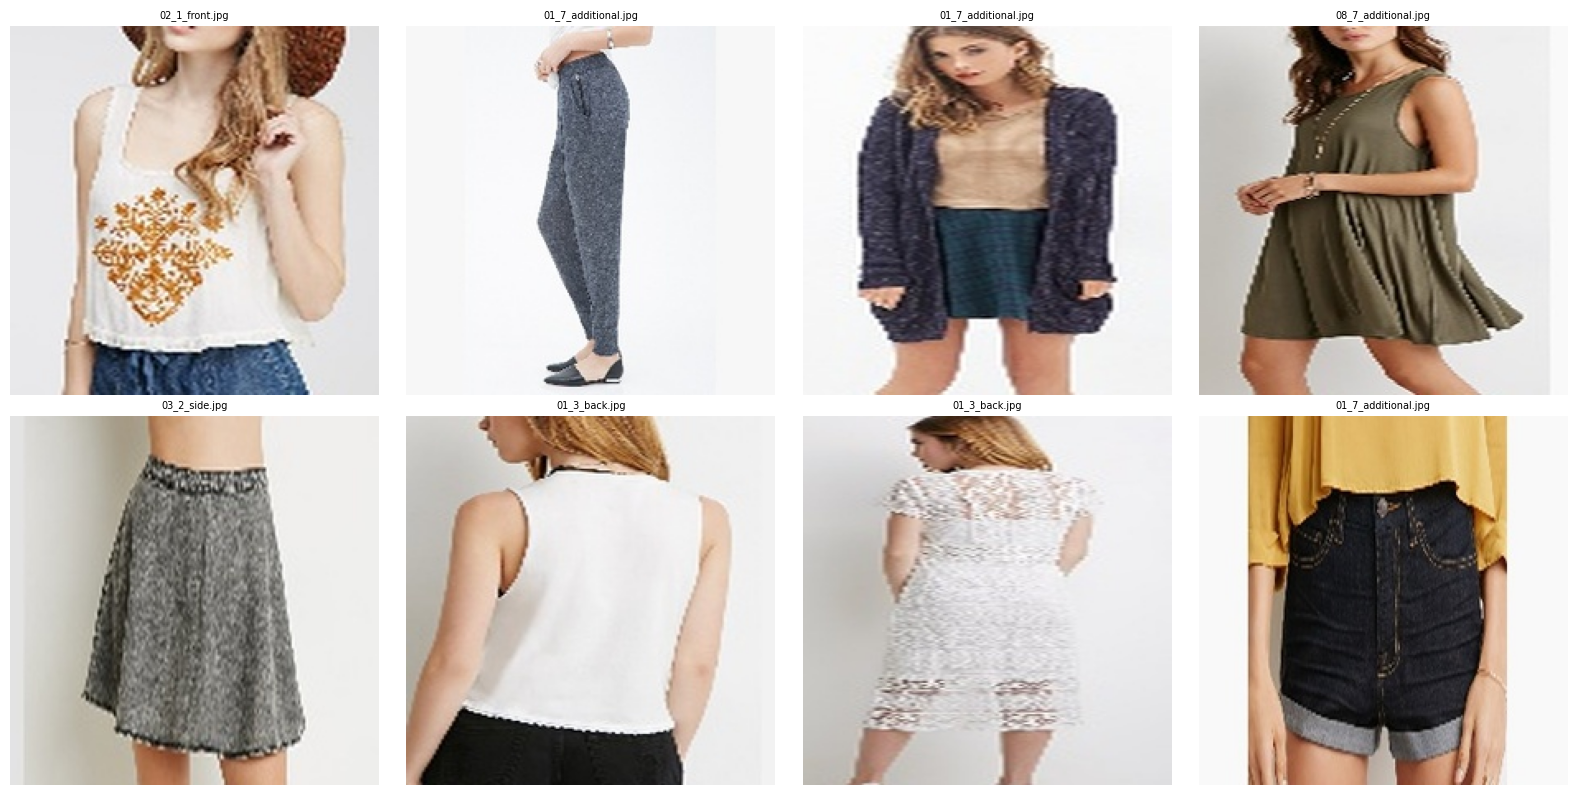

In [69]:
import random

# Get all cropped image paths
all_crops = []
for root, dirs, files in os.walk(CROP_DIR):
    for f in files:
        if f.endswith('.jpg'):
            all_crops.append(os.path.join(root, f))

print(f"Total cropped images found: {len(all_crops)}")

# Sample 8 random ones
random.seed(99)
samples = random.sample(all_crops, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, crop_path in enumerate(samples):
    axes[i].imshow(Image.open(crop_path))
    axes[i].set_title(crop_path.split('/')[-1], fontsize=7)
    axes[i].axis("off")
plt.tight_layout()
plt.show()